# Fig.05 2x2 组合图（可动态调整 figsize）

这个 notebook 会用 `calibration_fixed_panel.csv` 和 `dbn_calibration_fixed_panel.csv`
重建 `fig05`/`fig05b` 的同构数据来源，只画 Beat F1，输出 2x2：
- DBN - SMC fold0 Beat F1 ｜GTZAN Beat F1
- CASM - SMC fold0 Beat F1 ｜GTZAN Beat F1

你可以把 `FIGSIZE` 改成 `(4, 3)` 或其它值，反复运行最后一个 cell 重新出图。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import matplotlib as mpl
mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 8.0,
    'axes.titlesize': 8.5,
    'axes.labelsize': 7.5,
    'xtick.labelsize': 7.0,
    'ytick.labelsize': 7.0,
    'legend.fontsize': 7.0,
    'figure.titlesize': 9.5,
    'axes.edgecolor': '#252A30',
    'axes.linewidth': 0.65,
    'grid.color': '#D9DEE3',
    'grid.linewidth': 0.5,
})


In [2]:
# 你可以改这些参数，反复运行后面的绘图 cell
FIGSIZE = (4, 3)  # 比如 (8, 6) 或 (10, 7)
SEED_CASM = 20260904
SEED_DBN = 20260905
OUTPUT_STEM = 'fig05_casm_dbn_beatf1_scale_2x2'

ROOT = Path('/Users/hanyu/Documents/MacCodes/ICASSP2027/self-run-figures/figures-20260904-1443')
DATA_DIR = ROOT / 'data'
FIGURE_DIR = ROOT / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

CASM_PATH = DATA_DIR / 'calibration_fixed_panel.csv'
DBN_PATH = DATA_DIR / 'dbn_calibration_fixed_panel.csv'

# Color + marker style（和脚本中的风格保持一致）
BLUE = '#2563A6'
BLUE_LIGHT = '#9BC4E2'
ORANGE = '#D97706'
GREY = '#7B828A'
CHARCOAL = '#252A30'


In [3]:
casm_all = pd.read_csv(CASM_PATH)
dbn_all = pd.read_csv(DBN_PATH)

# 只要 fig05/fig05b 中 scale 的 1F/2F/4F/7F
SCALES = [1, 2, 4, 7]
scale_labels = ['1F', '2F', '4F', '7F']
casm = casm_all[casm_all.tuning_size.isin(SCALES)].copy()
dbn = dbn_all[dbn_all.tuning_size.isin(SCALES)].copy()

casm['scale'] = casm['tuning_size'].astype(int).astype(str) + 'F'
dbn['scale'] = dbn['tuning_size'].astype(int).astype(str) + 'F'

# Direct 基线要保留在完整表里（Direct 在 0F，筛选后会丢掉）
casm_direct = casm_all[casm_all.family == 'direct'].iloc[0]
dbn_direct = dbn_all[dbn_all.family == 'direct'].iloc[0]

print('casm rows:', len(casm), 'dbn rows:', len(dbn))
print('has casm direct:', (casm_all.family == 'direct').sum(), 'has dbn direct:', (dbn_all.family == 'direct').sum())


casm rows: 64 dbn rows: 64
has casm direct: 1 has dbn direct: 1


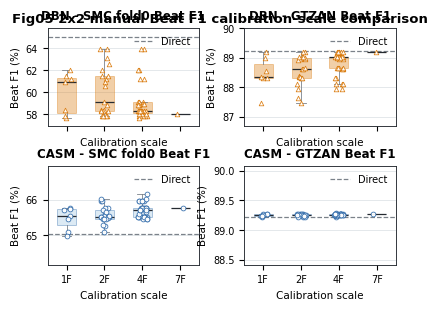

In [4]:
def plot_beat_f1_axis(ax, table, panel_prefix, direct_row, method_label, color, marker, seed, title):
    # panel_prefix: 'smc' 或 'gtzan'，对应列 smc_beat_fmeasure / gtzan_beat_fmeasure
    metric_col = f'{panel_prefix}_beat_fmeasure'
    direct_value = 100.0 * float(direct_row[metric_col])

    ax.axhline(direct_value, color=GREY, lw=0.9, ls='--', label='Direct')

    rng = np.random.default_rng(seed)
    positions = np.arange(len(SCALES))
    values_by_scale = []

    for position, scale in zip(positions, scale_labels):
        subset = table[table['scale'] == scale]
        vals = 100.0 * subset[metric_col].dropna().to_numpy()
        if len(vals) == 0:
            raise RuntimeError(f'No values for {method_label} {panel_prefix} scale {scale}')
        values_by_scale.append(vals)

        jitter = rng.uniform(-0.12, 0.12, size=len(vals))
        ax.scatter(
            np.full(len(vals), position) + jitter,
            vals,
            s=12 if marker == 'o' else 11,
            marker=marker,
            facecolor='white',
            edgecolor=color,
            linewidth=0.55,
            alpha=0.95,
            zorder=3,
        )

    ax.boxplot(
        values_by_scale,
        positions=positions,
        widths=0.5,
        showfliers=False,
        patch_artist=True,
        medianprops={'color': CHARCOAL, 'lw': 0.9},
        whiskerprops={'color': GREY, 'lw': 0.6},
        capprops={'color': GREY, 'lw': 0.6},
        boxprops={'facecolor': BLUE_LIGHT if method_label == 'CASM' else ORANGE, 'edgecolor': color, 'alpha': 0.35, 'lw': 0.7},
    )

    all_values = np.concatenate(values_by_scale + [np.array([direct_value])])
    data_min = float(np.nanmin(all_values))
    data_max = float(np.nanmax(all_values))
    pad = max(0.8, (data_max - data_min) * 0.10)
    if not np.isfinite(data_min) or not np.isfinite(data_max):
        ax.set_ylim(0, 100)
    elif data_max <= data_min:
        pad = max(0.8, abs(data_min) * 0.05 + 0.8)
        ax.set_ylim(data_min - pad, data_max + pad)
    else:
        ax.set_ylim(max(0.0, data_min - pad), min(100.0, data_max + pad))

    ax.set_xticks(positions, scale_labels)
    ax.set_xlabel('Calibration scale')
    ax.set_ylabel('Beat F1 (%)')
    ax.set_title(title, loc='center', fontweight='bold')
    ax.grid(axis='y')
    ax.legend(frameon=False, loc='best')
    return values_by_scale


def build_2x2_beatf1(casm_df, dbn_df, casm_direct_row, dbn_direct_row, figsize=(6, 4.5)):
    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True, sharey=False)

    # Top row: DBN
    plot_beat_f1_axis(
        axes[0, 0],
        dbn_df,
        panel_prefix='smc',
        direct_row=dbn_direct_row,
        method_label='DBN',
        color=ORANGE,
        marker='^',
        seed=SEED_DBN,
        title='DBN - SMC fold0 Beat F1',
    )
    plot_beat_f1_axis(
        axes[0, 1],
        dbn_df,
        panel_prefix='gtzan',
        direct_row=dbn_direct_row,
        method_label='DBN',
        color=ORANGE,
        marker='^',
        seed=SEED_DBN + 1,
        title='DBN - GTZAN Beat F1',
    )

    # Bottom row: CASM
    plot_beat_f1_axis(
        axes[1, 0],
        casm_df,
        panel_prefix='smc',
        direct_row=casm_direct_row,
        method_label='CASM',
        color=BLUE,
        marker='o',
        seed=SEED_CASM,
        title='CASM - SMC fold0 Beat F1',
    )
    plot_beat_f1_axis(
        axes[1, 1],
        casm_df,
        panel_prefix='gtzan',
        direct_row=casm_direct_row,
        method_label='CASM',
        color=BLUE,
        marker='o',
        seed=SEED_CASM + 1,
        title='CASM - GTZAN Beat F1',
    )

    fig.subplots_adjust(wspace=0.30, hspace=0.40, top=0.93, bottom=0.14, left=0.11, right=0.98)
    return fig, axes

fig, axes = build_2x2_beatf1(
    casm,
    dbn,
    casm_direct,
    dbn_direct,
    figsize=FIGSIZE
)
fig.suptitle('Fig05 2x2 manual Beat F1 calibration-scale comparison', x=0.02, ha='left', fontweight='bold')
plt.show()


In [ ]:
out_png = FIGURE_DIR / f'{OUTPUT_STEM}.png'
out_pdf = FIGURE_DIR / f'{OUTPUT_STEM}.pdf'
out_svg = FIGURE_DIR / f'{OUTPUT_STEM}.svg'

# 注意：如需不同尺寸，先改 FIGSIZE 再运行这个 cell
fig, _ = build_2x2_beatf1(
    casm,
    dbn,
    casm_direct,
    dbn_direct,
    figsize=FIGSIZE
)
fig.suptitle('Fig05 2x2 manual Beat F1 calibration-scale comparison', x=0.02, ha='left', fontweight='bold')
fig.savefig(out_png, dpi=320)
fig.savefig(out_pdf)
fig.savefig(out_svg)
plt.show()
print('saved:', out_png)
